# K-Means 클러스터링 — VIIRS 야간 밝기

읍면동 단위 2019–2026 야간 밝기 데이터를 K-Means로 군집화.  
Elbow Method로 최적 k를 정하고, 시군구 단위로 정리.

## 1. 환경 설정

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore', category=RuntimeWarning)

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

FEATURES = [
    'nightlight_2019', 'nightlight_2020', 'nightlight_2021', 'nightlight_2022',
    'nightlight_2023', 'nightlight_2024', 'nightlight_2025', 'nightlight_2026',
]

CLUSTER_NAMES = {
    0: '중광도',
    1: '저광도',
    2: '고광도',
}

## 2. 데이터 로드

In [2]:
df = pd.read_csv('viirs_emd_2019_2026.csv', encoding='utf-8-sig')

print(df.shape)
df.head()

(4516, 10)


,EMD_CD,EMD_NM,nightlight_2019,nightlight_2020,nightlight_2021,nightlight_2022,nightlight_2023,nightlight_2024,nightlight_2025,nightlight_2026
0,11110101,청운동,33.6517,33.0500,35.2775,31.8800,27.1892,27.9531,28.6347,38.6717
1,11110102,신교동,49.1583,46.6658,47.6808,46.6883,39.9933,39.4558,41.2825,50.9575
2,11110107,적선동,66.2550,66.8358,67.6600,71.5083,76.9333,74.3125,76.1825,82.7700
3,11110109,누상동,34.8829,34.6092,33.8883,34.0271,32.3637,32.2987,34.0129,40.4500
4,11110111,옥인동,29.8583,28.6421,27.0700,26.9987,26.0258,25.3633,25.7900,33.6838


## 3. 전처리

- 클러스터링 feature: 8개 연도 야간 밝기
- 결측값 제거
- `StandardScaler` 적용 (K-Means는 거리 기반이므로 스케일 통일 필요)

In [3]:
df_clean = df.dropna(subset=FEATURES).copy()
X = df_clean[FEATURES]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'원본: {len(df)}행 -> 결측 제거 후: {len(df_clean)}행')

원본: 4516행 -> 결측 제거 후: 4516행


## 4. 최적 k 탐색 — 엘보우 방법

k=2~10 범위에서 inertia를 비교하고, 그래프에서 꺾이는 지점을 확인

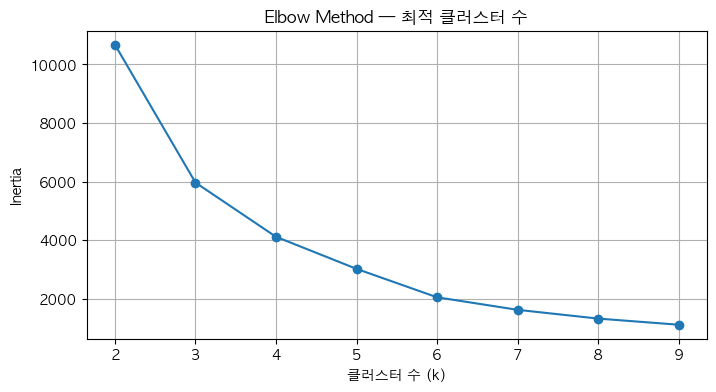

In [4]:
inertias = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker='o')
plt.xlabel('클러스터 수 (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — 최적 클러스터 수')
plt.xticks(k_range)
plt.grid(True)
plt.show()

## 5. K-Means 실행 (k=3)

엘보우 그래프 보니까 k=2→3에서 꺾임이 제일 큼. 그래서 k=3으로 정함.


In [5]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
df_clean['cluster'] = kmeans.fit_predict(X_scaled)

print('클러스터 고유값:', np.unique(df_clean['cluster']))
print('클러스터별 읍면동 수:')
print(df_clean['cluster'].value_counts().sort_index())

클러스터 고유값: [0 1 2]
클러스터별 읍면동 수:
cluster
0    1200
1    2717
2     599
Name: count, dtype: int64


## 6. 클러스터 해석

클러스터별 평균 밝기랑 대표 지역을 확인.

In [6]:
print('=== 클러스터별 평균 밝기 ===')
print(df_clean.groupby('cluster')[FEATURES].mean().round(2))

for cluster_id, name in CLUSTER_NAMES.items():
    print(f'\n=== {name} (cluster {cluster_id}) 상위 5개 읍면동 ===')
    top5 = (
        df_clean[df_clean['cluster'] == cluster_id]
        .nlargest(5, 'nightlight_2023')[['EMD_NM', 'nightlight_2023']]
    )
    print(top5.to_string(index=False))

=== 클러스터별 평균 밝기 ===
         nightlight_2019  nightlight_2020  nightlight_2021  nightlight_2022  \
cluster                                                                       
0                  35.02            35.17            36.47            38.45   
1                   5.70             5.77             6.12             6.48   
2                  70.00            70.31            70.90            75.24   

         nightlight_2023  nightlight_2024  nightlight_2025  nightlight_2026  
cluster                                                                      
0                  37.75            39.05            39.76            42.22  
1                   6.37             6.55             6.74             7.20  
2                  74.77            76.85            77.70            81.80  

=== 중광도 (cluster 0) 상위 5개 읍면동 ===
EMD_NM  nightlight_2023
 중앙동4가          67.9713
  곡반정동          64.4619
   원창동          63.9065
   마산동          60.4077
   운서동          60.0359

=== 저광도 (clust

## 7. 시군구 단위 집계

- `EMD_CD` 앞 5자리 = 법정동 시군구 코드 (`legal5`)
- `legal_to_kosis_sgg.csv`로 KOSIS 코드 변환
- 읍면동별 클러스터를 시군구 단위로 올릴 때는 최빈값 사용


In [7]:
# 법정동 코드 → KOSIS 코드 변환 (2_sgg_code_mapping.ipynb 결과)
map_sgg = pd.read_csv('legal_to_kosis_sgg.csv', encoding='utf-8-sig', dtype=str)
map_sgg = map_sgg.dropna(subset=['KOSIS_SGG_CODE']).drop_duplicates('legal5')

df_clean['legal5'] = df_clean['EMD_CD'].astype(str).str.zfill(8).str[:5]
df_clean = df_clean.merge(
    map_sgg[['legal5', 'KOSIS_SGG_CODE', 'KOSIS_SGG_NM']],
    on='legal5',
    how='left',
)

unmapped = df_clean['KOSIS_SGG_CODE'].isna().sum()
if unmapped:
    print(f'⚠ KOSIS 코드 매칭 실패 읍면동: {unmapped}개')
    print('→ 2_sgg_code_mapping.ipynb 를 먼저 실행하세요.')
else:
    print('✓ 모든 읍면동 KOSIS 코드 매칭 완료')

sgg = df_clean.groupby('KOSIS_SGG_CODE').agg(
    SGG_NM=('KOSIS_SGG_NM', 'first'),
    nightlight_avg=('nightlight_2023', 'mean'),
    cluster=('cluster', lambda x: x.mode()[0]),
).reset_index()

sgg.rename(columns={'KOSIS_SGG_CODE': 'SGG_CODE'}, inplace=True)
sgg['cluster_name'] = sgg['cluster'].map(CLUSTER_NAMES)

print(f'\n시군구 수: {len(sgg)}')
print('\n=== 클러스터별 시군구 수 ===')
print(sgg['cluster_name'].value_counts())

✓ 모든 읍면동 KOSIS 코드 매칭 완료



시군구 수: 248

=== 클러스터별 시군구 수 ===
cluster_name
저광도    161
중광도     59
고광도     28
Name: count, dtype: int64


## 8. 지역별 확인

서울(KOSIS 11)이랑 전남(KOSIS 36) 시군구 클러스터를 비교.

In [8]:
cols = ['SGG_CODE', 'SGG_NM', 'nightlight_avg', 'cluster_name']

print('=== 서울 (KOSIS 11) ===')
print(sgg[sgg['SGG_CODE'].str.startswith('11')][cols].to_string(index=False))

print('\n=== 전남 (KOSIS 36) ===')
print(sgg[sgg['SGG_CODE'].str.startswith('36')][cols].to_string(index=False))

=== 서울 (KOSIS 11) ===
SGG_CODE SGG_NM  nightlight_avg cluster_name
   11010    종로구       61.153505          고광도
   11020     중구      116.211756          고광도
   11030    용산구       63.014543          고광도
   11040    성동구       68.623413          고광도
   11050    광진구       60.120014          중광도
   11060   동대문구       72.366420          고광도
   11070    중랑구       60.106917          고광도
   11080    성북구       63.799767          고광도
   11090    강북구       39.403750          중광도
   11100    도봉구       37.821600          중광도
   11110    노원구       40.493880          중광도
   11120    은평구       44.907909          중광도
   11130   서대문구       55.485759          고광도
   11140    마포구       66.508252          고광도
   11150    양천구       60.621333          고광도
   11160    강서구       43.067585          중광도
   11170    구로구       50.849850          중광도
   11180    금천구       54.240367          고광도
   11190   영등포구       77.490510          고광도
   11200    동작구       52.989389          중광도
   11210    관악구       37.096933  

## 9. CSV 저장

In [9]:
sgg.to_csv('kmeans_sgg_cluster.csv', index=False, encoding='utf-8-sig')

print("저장 완료: kmeans_sgg_cluster.csv")
print(f"저장된 시군구 수: {len(sgg)}")
sgg.head(10)

저장 완료: kmeans_sgg_cluster.csv
저장된 시군구 수: 248


,SGG_CODE,SGG_NM,nightlight_avg,cluster,cluster_name
0,11010,종로구,61.153505,2,고광도
1,11020,중구,116.211756,2,고광도
2,11030,용산구,63.014543,2,고광도
3,11040,성동구,68.623413,2,고광도
4,11050,광진구,60.120014,0,중광도
5,11060,동대문구,72.366420,2,고광도
6,11070,중랑구,60.106917,2,고광도
7,11080,성북구,63.799767,2,고광도
8,11090,강북구,39.403750,0,중광도
9,11100,도봉구,37.821600,0,중광도
